In [1]:
import pickle
import numpy as np
import pandas as pd
import os
from iblatlas.atlas import BrainRegions
from datetime import datetime

from one.api import ONE
one= ONE()

In [2]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

# Load data

In [3]:
import brainwidemap
# this dataframe holds a summary of all the sessions
# and for us importantly, the eids and pids
bwm_df = brainwidemap.bwm_query()  # each row of this dataframe is a recording

n_sessions = bwm_df["eid"].unique().shape[0]
n_insertions = bwm_df["pid"].unique().shape[0]
print(
    f"{n_sessions} sessions with {n_insertions} individual neuropixel recordings"
)
# bwm_df.head()
bwm_pid = bwm_df['pid'].unique()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
459 sessions with 699 individual neuropixel recordings


## LDA axis

In [4]:
# cluster_df = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# session_cluster = pd.read_parquet(data_path+'cluster_per_session')
lda = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')
lda = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut18-06-2026')
lda = lda.rename(columns={0: 'lda_1'})

lda_eid = lda.loc[lda['session'].isin(list(bwm_df.eid)), 'session']
lda_pid = bwm_df.loc[bwm_df['eid'].isin(lda_eid), 'pid']

In [5]:
print(len(lda_eid))
print(len(lda_pid))

244
380


## Available neural files

In [6]:
save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/neuron_files/'
# save_states_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/neuron_files/'

filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)]
print(len(filepaths))

464


# Design matrix 

In [7]:
# Initialize IBL Brain Atlas and target regions
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']
regions = BrainRegions()

def get_simplified_area(col_name, filter_sessions=False):
    """Traces an Allen ID/acronym back up to our 6 target regions."""
    raw_acronym = col_name.split('_neuron_')[0]
    allen_ids = regions.acronym2id(raw_acronym)
    beryl_ids = regions.remap(allen_ids, source_map='Allen', target_map='Beryl')
    ancestor = regions.id2acronym(beryl_ids)[0]
    if filter_sessions:
        if ancestor in BRAIN_REGIONS:
            return ancestor
        else:
            return None
    else:
        return ancestor

In [8]:
relevant_pids = lda_pid.copy()

In [9]:
from sklearn.preprocessing import OneHotEncoder

# --- Parameters ---
MAX_TRIALS_TO_PROCESS = 400
FS = 60  # Sampling rate in Hz
# Musall et al. uses a specific time window for task events. 
# Let's capture from 0 seconds to 1.0 second after the goCue (60 bins total).
EVENT_LAG_BINS = int(1.0 * FS) 

path_dir = prefix + 'representation_learning_variability/paper-individuality/data/neuron_files/'

def get_simplified_area(col_name, filter_sessions=False):
    # Dummy placeholder based on your context script
    if '_spike_count' in col_name:
        return col_name.split('_')[0]
    return None

summary_records = []

# Loop through your session PIDs
for pid in relevant_pids[:1]:
    filepath = os.path.join(path_dir, f'states_neurons_file_{pid}')
    try:
        with open(filepath, 'rb') as f:
            raw_data = pickle.load(f)
            
        state_with_spikes = raw_data.dropna(subset=['Bin', 'most_likely_states']).reset_index(drop=True)
        if state_with_spikes.empty:
            continue
            
        pid_name = state_with_spikes['session_pid'].iloc[0]
        session_name = state_with_spikes['session'].iloc[0]
        
        # --- 1. FILTER TRIALS (as per your script) ---
        all_events = np.array(state_with_spikes['goCueTrigger_times'].unique())
        events_subset = all_events[:MAX_TRIALS_TO_PROCESS]
        
        # Filter dataframe to only include rows belonging to these top trials
        session_df = state_with_spikes[state_with_spikes['goCueTrigger_times'].isin(events_subset)].reset_index(drop=True)
        if session_df.empty:
            continue

        # --- 2. BUILD MOVEMENT DESIGN MATRIX (Discrete States) ---
        # "paw", "whisk", and "lick" columns contain discrete states. We one-hot encode them.
        movement_cols = ['paw', 'whisk', 'lick']
        
        # Ensure there are no NaNs in movement states for encoding
        session_df[movement_cols] = session_df[movement_cols].fillna('unknown')
        
        encoder = OneHotEncoder(sparse_output=False, drop='first') # drop='first' avoids multicollinearity
        movement_encoded = encoder.fit_transform(session_df[movement_cols])
        movement_feature_names = encoder.get_feature_names_out(movement_cols)
        
        df_movement = pd.DataFrame(movement_encoded, columns=movement_feature_names)

        # --- 3. BUILD TASK EVENT DESIGN MATRIX (goCue Alignment) ---
        # We find the exact bin where 'goCueTrigger_times' changes/occurs.
        # In binned data, the event onset is typically where the registered time matches the stream bin time.
        # Here we look for unique event stamps to mark the onset frame:
        session_df['goCue_onset'] = 0
        # Identify rows where a trial starts or the goCue time is first introduced
        onset_indices = session_df.drop_duplicates(subset=['goCueTrigger_times']).index
        session_df.loc[onset_indices, 'goCue_onset'] = 1
        
        # Generate time-lagged features for the event (Ridge Basis)
        # This creates columns: goCue_lag_0, goCue_lag_1, ..., goCue_lag_N
        lag_features = {}
        for lag in range(EVENT_LAG_BINS):
            lag_features[f'goCue_lag_{lag}'] = session_df['goCue_onset'].shift(lag).fillna(0)
            
        df_events = pd.DataFrame(lag_features)

        # --- 4. COMBINE TO CREATE THE FINAL DESIGN MATRIX (X) ---
        X = pd.concat([df_events, df_movement], axis=1)
        # Add a constant intercept column
        X.insert(0, 'intercept', 1)

        # --- 5. EXTRACT TARGET VARIABLES (y) PER NEURON ---
        spike_columns = [col for col in session_df.columns if '_spike_count' in col]
        
        for col in spike_columns:
            area = get_simplified_area(col, filter_sessions=False)
            if not area:  
                continue
            
            # y vector is the vector of spike counts for this neuron across all bins
            y = session_df[col].values
            
            # --- READY FOR ENCODING MODEL ---
            # X matrix shape: (num_bins, num_features)
            # y vector shape: (num_bins,)
            
            # Store data structures or summary metadata for the next stage
            summary_records.append({
                'pid': pid_name,
                'neuron_id': col,
                'brain_area': area,
                'X_design': X.copy(),  # Design matrix containing task & movement predictors
                'y_spikes': y          # Neural activity target
            })
            
    except Exception as e:
        print(f"Error processing {pid}: {e}")

In [10]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# --- Parameters for the Model ---
# Define a range of regularization strengths (alpha) to test via cross-validation
ALPHA_GRID = np.logspace(-3, 5, 9) 

# Setup 5-fold Cross-Validation to evaluate model performance without overfitting
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# This list will hold the final results for all processed neurons
model_results = []

# Iterate through the summary_records we built in the design matrix stage
for record in summary_records:
    pid = record['pid']
    neuron_id = record['neuron_id']
    brain_area = record['brain_area']
    
    # Extract the design matrix X and response variable y
    # We drop the explicit 'intercept' column if using sklearn's built-in fit_intercept=True
    X = record['X_design'].drop(columns=['intercept'], errors='ignore').values
    y = record['y_spikes']
    
    # Pre-allocate array for cross-validated predictions
    y_pred_cv = np.zeros_like(y, dtype=float)
    
    # Keep track of coefficients across folds to evaluate stability
    fold_coefficients = []
    
    # Perform manual cross-validation loop to gather true out-of-fold predictions
    for train_idx, val_idx in cv_strategy.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Initialize RidgeCV which automatically finds the best alpha within the training set
        model = RidgeCV(alphas=ALPHA_GRID, fit_intercept=True)
        model.fit(X_train, y_train)
        
        # Predict on the left-out validation fold
        y_pred_cv[val_idx] = model.predict(X_val)
        fold_coefficients.append(model.coef_)
        
    # --- MODEL EVALUATION ---
    # Total Variance Explained (Cross-Validated R^2)
    # This reflects how well task + movement explain this neuron's single-trial variance
    cv_r2 = r2_score(y, y_pred_cv)
    
    # Train a final model on 100% of the data to get the absolute best estimate of the kernels
    final_model = RidgeCV(alphas=ALPHA_GRID, fit_intercept=True)
    final_model.fit(X, y)
    
    # Extract feature weights
    feature_names = record['X_design'].drop(columns=['intercept'], errors='ignore').columns.tolist()
    coefficients = final_model.coef_
    intercept = final_model.intercept_
    
    # --- GROUP COEFFICIENTS BY VARIABES (KERNELS) ---
    # Split weights into Task (goCue lags) vs Movement States
    task_features = [f for f in feature_names if 'goCue_lag' in f]
    movement_features = [f for f in feature_names if f not in task_features]
    
    # The task weights form the Time-Post-Stimulus kernel (PSTH filter)
    # Sorting ensures they are chronological from lag_0 to lag_N
    task_features_sorted = sorted(task_features, key=lambda x: int(x.split('_')[-1]))
    task_kernel_indices = [feature_names.index(f) for f in task_features_sorted]
    task_kernel_weights = coefficients[task_kernel_indices]
    
    # Movement state offsets
    movement_indices = [feature_names.index(f) for f in movement_features]
    movement_weights = {feature_names[i]: coefficients[i] for i in movement_indices}
    
    # Store results
    model_results.append({
        'pid': pid,
        'neuron_id': neuron_id,
        'brain_area': brain_area,
        'cv_variance_explained': max(0, cv_r2), # Floor at 0 if model performs worse than chance
        'best_alpha': final_model.alpha_,
        'intercept': intercept,
        'task_kernel': task_kernel_weights, # Time-series array of responses to goCue
        'movement_weights': movement_weights # Scalar adjustments for paw/whisk/lick states
    })

print(f"Successfully fit encoding models for {len(model_results)} neurons.")

Successfully fit encoding models for 118 neurons.


In [30]:
oi = pd.DataFrame(model_results)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a summary dataframe from results
results_summary = pd.DataFrame([
    {
        'pid': r['pid'],
        'neuron_id': r['neuron_id'],
        'brain_area': r['brain_area'],
        'cv_r2': r['cv_variance_explained'],
        'alpha': r['best_alpha'],
    }
    for r in model_results
])
print(results_summary.head())
print(f'\nTotal neurons: {len(results_summary)}')
print(f'Mean R²: {results_summary["cv_r2"].mean():.3f} ± {results_summary["cv_r2"].std():.3f}')

                                    pid                  neuron_id brain_area  \
0  7b05cccc-44f6-4491-a0ea-e38d6e95513d  PIR_neuron_39_spike_count        PIR   
1  7b05cccc-44f6-4491-a0ea-e38d6e95513d  PIR_neuron_63_spike_count        PIR   
2  7b05cccc-44f6-4491-a0ea-e38d6e95513d  PIR_neuron_67_spike_count        PIR   
3  7b05cccc-44f6-4491-a0ea-e38d6e95513d  PIR_neuron_70_spike_count        PIR   
4  7b05cccc-44f6-4491-a0ea-e38d6e95513d  PIR_neuron_73_spike_count        PIR   

      cv_r2     alpha  
0  0.003795    1000.0  
1  0.000130    1000.0  
2  0.002449     100.0  
3  0.000000  100000.0  
4  0.006861     100.0  

Total neurons: 118
Mean R²: 0.024 ± 0.130


/tmp/ipykernel_27243/2880430937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_summary, x='brain_area', y='cv_r2', ax=ax, palette='Set2')


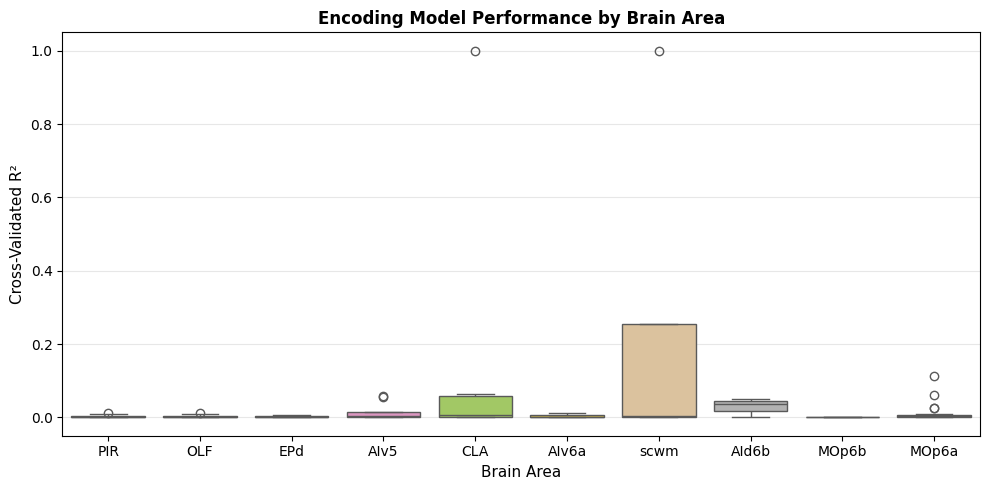

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=results_summary, x='brain_area', y='cv_r2', ax=ax, palette='Set2')
ax.set_xlabel('Brain Area', fontsize=11)
ax.set_ylabel('Cross-Validated R²', fontsize=11)
ax.set_title('Encoding Model Performance by Brain Area', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

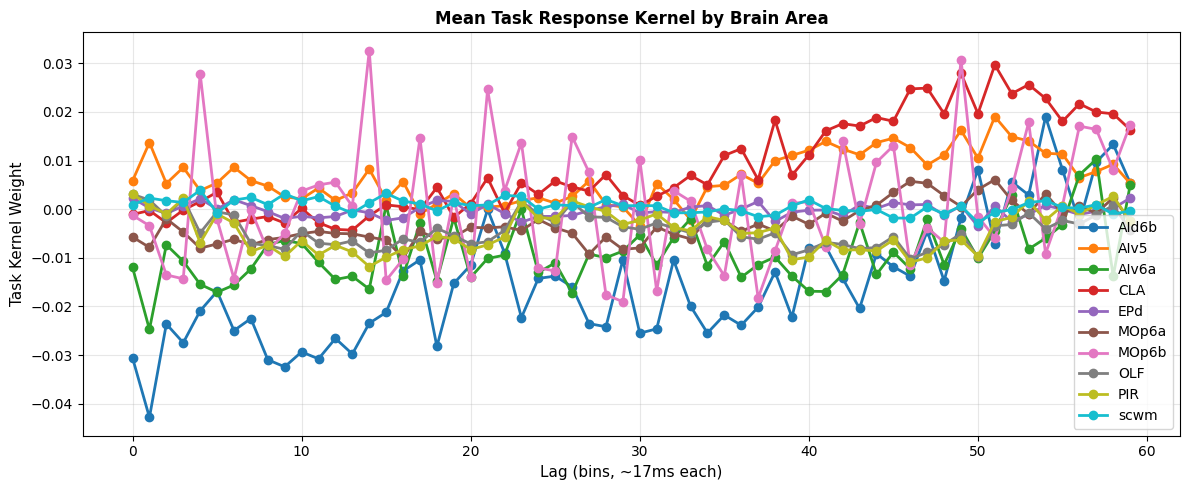

In [13]:
# Compute mean task kernel per brain area
brain_areas = results_summary['brain_area'].unique()
fig, ax = plt.subplots(figsize=(12, 5))

for area in sorted(brain_areas):
    area_results = [r for r in model_results if r['brain_area'] == area]
    kernels = [r['task_kernel'] for r in area_results]
    
    if kernels:
        # Pad to same length if needed
        max_len = max(len(k) for k in kernels)
        padded = np.array([np.pad(k, (0, max_len - len(k)), mode='constant') for k in kernels])
        mean_kernel = np.mean(padded, axis=0)
        ax.plot(mean_kernel, label=area, linewidth=2, marker='o')

ax.set_xlabel('Lag (bins, ~17ms each)', fontsize=11)
ax.set_ylabel('Task Kernel Weight', fontsize=11)
ax.set_title('Mean Task Response Kernel by Brain Area', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

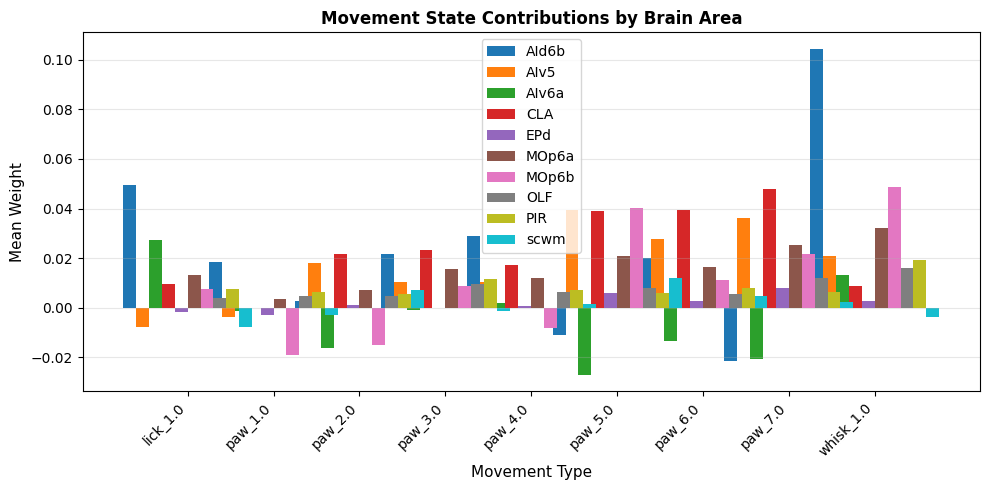

In [14]:
# Average movement weights by brain area
movement_summary = {}
for area in sorted(brain_areas):
    area_results = [r for r in model_results if r['brain_area'] == area]
    all_weights = {}
    
    for r in area_results:
        for feature, weight in r['movement_weights'].items():
            if feature not in all_weights:
                all_weights[feature] = []
            all_weights[feature].append(weight)
    
    movement_summary[area] = {f: np.mean(w) for f, w in all_weights.items()}

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
movements = sorted(set(f for area_dict in movement_summary.values() for f in area_dict.keys()))
x = np.arange(len(movements))
width = 0.15

for i, area in enumerate(sorted(brain_areas)):
    weights = [movement_summary[area].get(m, 0) for m in movements]
    ax.bar(x + i*width, weights, width, label=area)

ax.set_xlabel('Movement Type', fontsize=11)
ax.set_ylabel('Mean Weight', fontsize=11)
ax.set_title('Movement State Contributions by Brain Area', fontsize=12, fontweight='bold')
ax.set_xticks(x + width * (len(brain_areas) - 1) / 2)
ax.set_xticklabels(movements, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

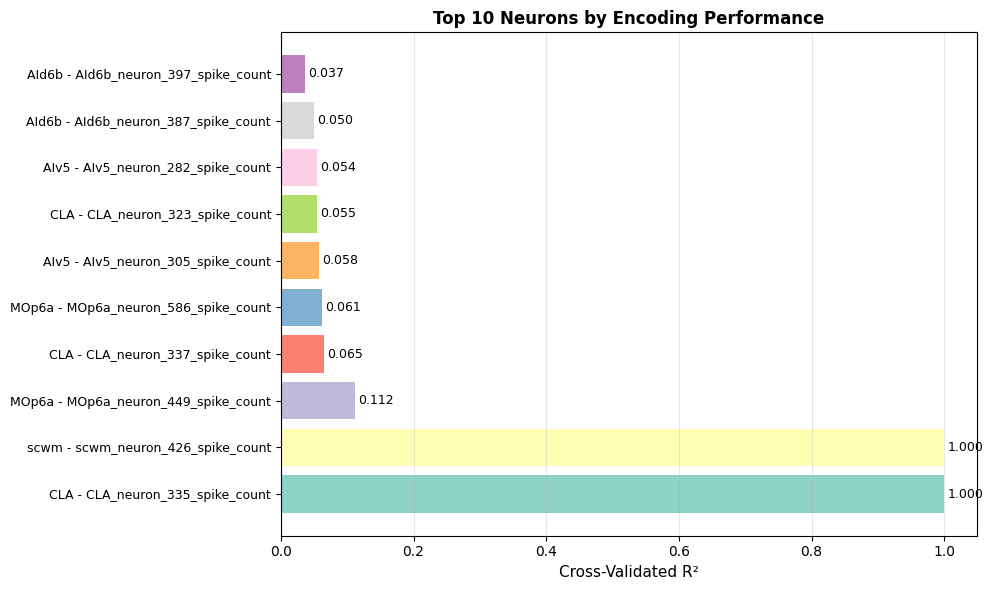

In [15]:
top_neurons = results_summary.nlargest(10, 'cv_r2')
fig, ax = plt.subplots(figsize=(10, 6))
colors = [plt.cm.Set3(i % 12) for i in range(len(top_neurons))]
bars = ax.barh(range(len(top_neurons)), top_neurons['cv_r2'].values, color=colors)
ax.set_yticks(range(len(top_neurons)))
ax.set_yticklabels([f"{row['brain_area']} - {row['neuron_id']}" 
                      for _, row in top_neurons.iterrows()], fontsize=9)
ax.set_xlabel('Cross-Validated R²', fontsize=11)
ax.set_title('Top 10 Neurons by Encoding Performance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, (idx, row) in enumerate(top_neurons.iterrows()):
    ax.text(row['cv_r2'] + 0.005, i, f"{row['cv_r2']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

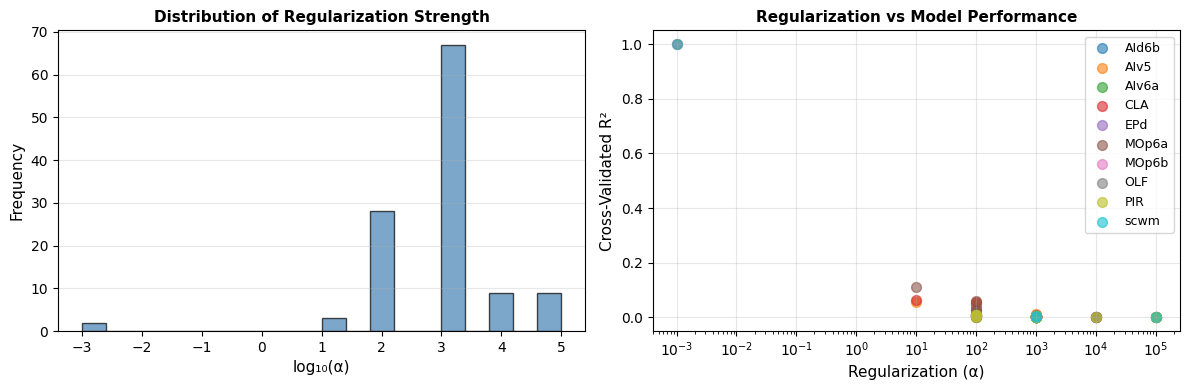

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of log(alpha)
ax1.hist(np.log10(results_summary['alpha']), bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('log₁₀(α)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Regularization Strength', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Alpha vs R²
for area in sorted(brain_areas):
    area_data = results_summary[results_summary['brain_area'] == area]
    ax2.scatter(area_data['alpha'], area_data['cv_r2'], label=area, alpha=0.6, s=50)

ax2.set_xscale('log')
ax2.set_xlabel('Regularization (α)', fontsize=11)
ax2.set_ylabel('Cross-Validated R²', fontsize=11)
ax2.set_title('Regularization vs Model Performance', fontsize=11, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Predicted vs Actual Firing Rates for Top Neurons
# We need to refit the models to capture predictions

from sklearn.linear_model import RidgeCV

top_n = 6
top_neurons_list = results_summary.nlargest(top_n, 'cv_r2').values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for plot_idx, (pid, neuron_id, brain_area, cv_r2, alpha) in enumerate(top_neurons_list):
    # Find the corresponding record
    record = next(r for r in summary_records if r['neuron_id'] == neuron_id)
    
    X = record['X_design'].drop(columns=['intercept'], errors='ignore').values
    y = record['y_spikes']
    
    # Fit final model on all data
    model = RidgeCV(alphas=ALPHA_GRID, fit_intercept=True)
    model.fit(X, y)
    y_pred = model.predict(X)
    
    ax = axes[plot_idx]
    ax.scatter(y, y_pred, alpha=0.5, s=20, edgecolor='none')
    
    # Add diagonal line (perfect prediction)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, alpha=0.7, label='Perfect')
    
    ax.set_xlabel('Actual Firing Rate (Hz)', fontsize=10)
    ax.set_ylabel('Predicted Firing Rate (Hz)', fontsize=10)
    ax.set_title(f'{brain_area} - R²={cv_r2:.3f}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual Firing Rates: Top 6 Neurons', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

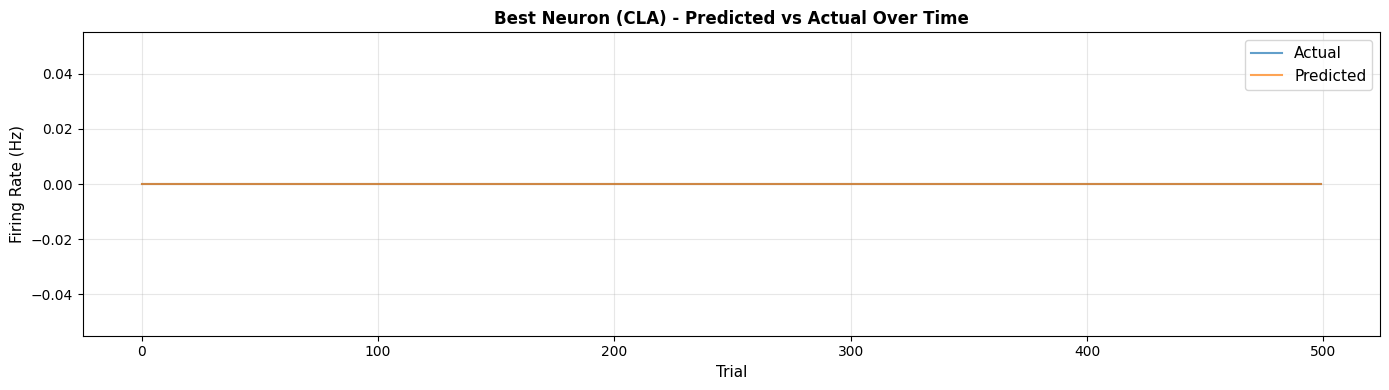

Best neuron: CLA_neuron_335_spike_count in CLA
Cross-validated R²: 1.0000
Actual FR: 0.00 ± 0.00 Hz
Predicted FR: 0.00 ± 0.00 Hz


In [23]:
# Time Series: Predicted vs Actual for Best Neuron

best_neuron = results_summary.nlargest(3, 'cv_r2').iloc[0]
record = next(r for r in summary_records if r['neuron_id'] == best_neuron['neuron_id'])

X = record['X_design'].drop(columns=['intercept'], errors='ignore').values
y = record['y_spikes']

model = RidgeCV(alphas=ALPHA_GRID, fit_intercept=True)
model.fit(X, y)
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(14, 4))

# Plot first 500 trials (or all if fewer)
plot_trials = min(500, len(y))
ax.plot(y[:plot_trials], label='Actual', alpha=0.7, linewidth=1.5)
ax.plot(y_pred[:plot_trials], label='Predicted', alpha=0.7, linewidth=1.5)

ax.set_xlabel('Trial', fontsize=11)
ax.set_ylabel('Firing Rate (Hz)', fontsize=11)
ax.set_title(f'Best Neuron ({best_neuron["brain_area"]}) - Predicted vs Actual Over Time', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best neuron: {best_neuron["neuron_id"]} in {best_neuron["brain_area"]}')
print(f'Cross-validated R²: {best_neuron["cv_r2"]:.4f}')
print(f'Actual FR: {y.mean():.2f} ± {y.std():.2f} Hz')
print(f'Predicted FR: {y_pred.mean():.2f} ± {y_pred.std():.2f} Hz')